# The Central Limit Theorem, starting from something *lopsided*

Last time we started from a uniform distribution — flat, but at least symmetric. This time we start from
something much less bell-curve-friendly: the **exponential distribution**. It's sharply peaked at zero,
has a long tail stretching to large values, can never go negative, and looks nothing like a bell curve:

$$p(x) = \lambda e^{-\lambda x}, \qquad x \geq 0$$

It shows up wherever you're modeling "time until something happens" — radioactive decay times, time
between bus arrivals, time between phone calls at a call center.

The claim of the Central Limit Theorem is that **none of that lopsidedness survives averaging**. Average
enough exponential draws together and you get the same symmetric bell curve as before, with the same
$1/\sqrt N$ narrowing. That the CLT doesn't care whether you start symmetric or wildly skewed is really
the whole point of the theorem, so this time we'll also track the *skewness* of the distribution of means
and watch it visibly decay toward zero.

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import skew

rng = np.random.default_rng(42)  # fixed seed so the notebook is reproducible


## 2. The underlying (lopsided) distribution

We'll draw individual numbers from an exponential distribution with a given `scale` ($=1/\lambda$, the
mean waiting time). NumPy's `rng.exponential(scale, size)` does exactly this. A histogram of raw draws
should look like a sharp spike at zero decaying into a long right-hand tail -- nothing like a bell curve.

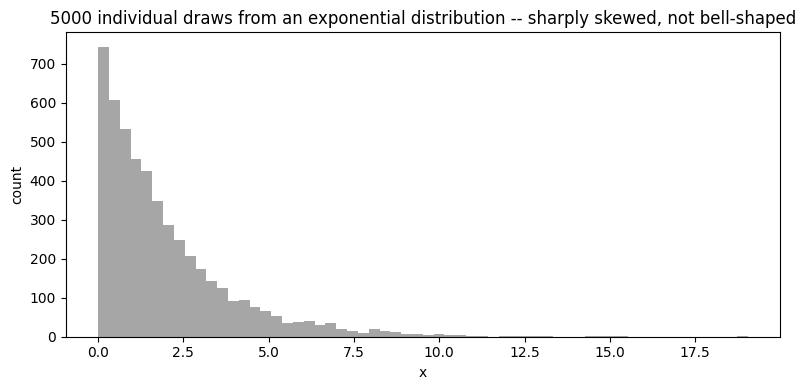

Raw sample mean  : 1.968  (theory: 2.000)
Raw sample std   : 1.972  (theory: 2.000, same as the mean -- a quirk of the exponential)
Raw sample skewness: 2.072  (theory: 2.0 -- strongly right-skewed; a Gaussian has skewness 0)


In [2]:
scale = 2.0  # this is 1/lambda: the mean of a single exponential draw

raw = rng.exponential(scale, 5000)

plt.figure(figsize=(8, 4))
plt.hist(raw, bins=60, color='gray', alpha=0.7)
plt.xlabel('x')
plt.ylabel('count')
plt.title('5000 individual draws from an exponential distribution -- sharply skewed, not bell-shaped')
plt.tight_layout()
plt.show()

print(f'Raw sample mean  : {raw.mean():.3f}  (theory: {scale:.3f})')
print(f'Raw sample std   : {raw.std():.3f}  (theory: {scale:.3f}, same as the mean -- a quirk of the exponential)')
print(f'Raw sample skewness: {skew(raw):.3f}  (theory: 2.0 -- strongly right-skewed; a Gaussian has skewness 0)')


Notice something specific to the exponential distribution: its mean and its standard deviation are
*equal* ($\mu_x = \sigma_x = 1/\lambda$). And it has a fixed, nonzero **skewness of exactly 2**, however
big or small `scale` is -- a permanent lopsidedness that has nothing to do with sample size. That skewness
of 2 is what we're going to watch disappear as we start averaging.

## 3. Generating the list of means

Same recipe as before: draw $N$ random numbers -- this time from the exponential distribution -- average
them into a single number, and repeat that whole process `n_experiments` times, collecting every average
into a list called `means`.

In [3]:
def sample_means(n_experiments, N, scale):
    """Run n_experiments independent experiments; each draws N exponential randoms and keeps their mean."""
    means = []
    for _ in range(n_experiments):
        sample = rng.exponential(scale, N)
        means.append(sample.mean())
    return np.array(means)

# a single quick example: 30 numbers per experiment, one experiment
one_mean = sample_means(n_experiments=1, N=30, scale=scale)
print('One experiment, N=30 exponential numbers averaged into a single value:', one_mean)


One experiment, N=30 exponential numbers averaged into a single value: [1.98353843]


## 4. Watching the bell curve emerge

Fix $N=30$ (numbers averaged per experiment) and vary how many experiments we run: 1, 10, 50, 100, 1000.

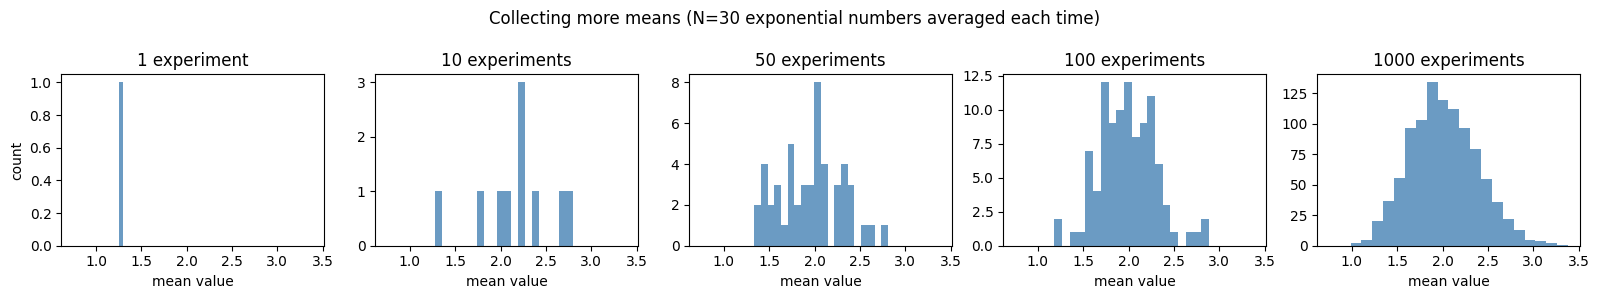

In [4]:
N_fixed = 30
experiment_counts = [1, 10, 50, 100, 1000]

fig, axes = plt.subplots(1, len(experiment_counts), figsize=(16, 3), sharex=True, sharey=False)
for ax, n_exp in zip(axes, experiment_counts):
    means = sample_means(n_exp, N_fixed, scale)
    ax.hist(means, bins=20, color='steelblue', alpha=0.8)
    ax.set_title(f'{n_exp} experiment' + ('s' if n_exp > 1 else ''))
    ax.set_xlabel('mean value')
axes[0].set_ylabel('count')
plt.suptitle(f'Collecting more means (N={N_fixed} exponential numbers averaged each time)')
plt.tight_layout()
plt.show()


Same story as with the uniform distribution: 1 or 10 experiments give you a few scattered points, and
by a few hundred a clear bell shape has formed -- but this time it emerged from averaging numbers drawn
from a distribution that itself looked nothing like a bell.

## 5. What happens if we average more (or fewer) numbers per mean?

Fix a large number of experiments and vary $N$, the count of exponential numbers averaged into each mean.
This time we'll also track the **skewness** of each resulting distribution of means, to watch the original
lopsidedness (skewness = 2) get washed out.

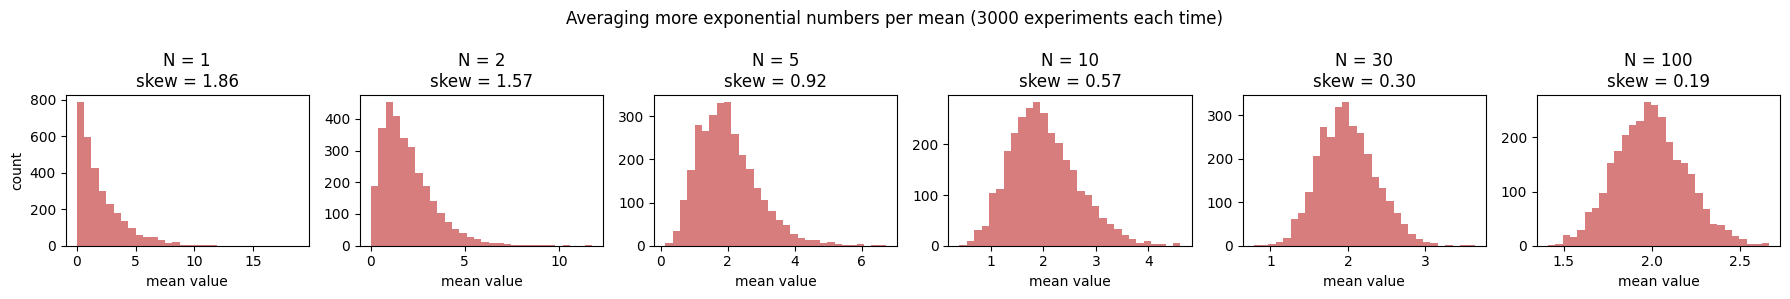

In [5]:
n_experiments_fixed = 3000
N_values = [1, 2, 5, 10, 30, 100]

fig, axes = plt.subplots(1, len(N_values), figsize=(18, 3), sharex=False, sharey=False)
skewness_by_N = []
for ax, N in zip(axes, N_values):
    means = sample_means(n_experiments_fixed, N, scale)
    ax.hist(means, bins=30, color='indianred', alpha=0.8)
    sk = skew(means)
    skewness_by_N.append(sk)
    ax.set_title(f'N = {N}\nskew = {sk:.2f}')
    ax.set_xlabel('mean value')
axes[0].set_ylabel('count')
plt.suptitle(f'Averaging more exponential numbers per mean ({n_experiments_fixed} experiments each time)')
plt.tight_layout()
plt.show()


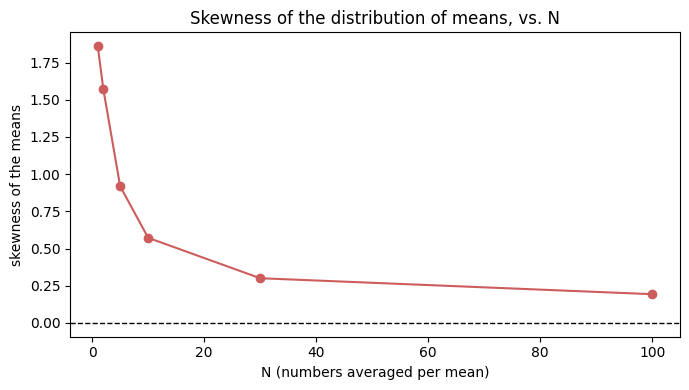

In [6]:
plt.figure(figsize=(7, 4))
plt.plot(N_values, skewness_by_N, 'o-', color='indianred')
plt.axhline(0, ls='--', color='k', lw=1)
plt.xlabel('N (numbers averaged per mean)')
plt.ylabel('skewness of the means')
plt.title('Skewness of the distribution of means, vs. N')
plt.tight_layout()
plt.show()


At $N=1$ the "mean" is just the original exponential draw itself, skewness $\approx 2$, sharp spike and
long tail. By $N=100$ the skewness has collapsed to nearly zero and the histogram already looks
symmetric and bell-shaped. Theory actually predicts exactly how fast this happens: the skewness of a mean
of $N$ i.i.d. draws falls off as $\text{skew}_x/\sqrt N$ -- so skewness 2 at $N=1$ should be roughly 0.2 by
$N=100$, which is close to what the plot shows.

This is the genuinely surprising part of the Central Limit Theorem: it doesn't just narrow the
distribution, it actively erases the *shape* of whatever you started with -- skewed, spiky, bounded,
anything -- given enough terms in the average.

## 6. Fitting a Gaussian to the means

Now the quantitative check. Generate one large set of means (large $N$, many experiments) and fit it with

$$G(x;A,\mu,\sigma) = A\exp\!\left[-\tfrac12\left(\frac{x-\mu}{\sigma}\right)^2\right]$$

then compare the fitted $\mu$ and $\sigma$ to what CLT predicts:

$$\mu_{\rm mean} = \mu_x = \text{scale} \qquad\qquad \sigma_{\rm mean} = \frac{\sigma_x}{\sqrt N} = \frac{\text{scale}}{\sqrt N}$$

(using $\sigma_x = \text{scale}$, the standard deviation of a single exponential draw).

In [7]:
def gaussian(x, A, mu, sigma):
    return A * np.exp(-0.5 * ((x - mu) / sigma) ** 2)

N = 30
n_experiments = 5000
means = sample_means(n_experiments, N, scale)

nbins = 40
counts, edges = np.histogram(means, bins=nbins)
centers = 0.5 * (edges[:-1] + edges[1:])

p0 = [counts.max(), means.mean(), means.std()]
popt, pcov = curve_fit(gaussian, centers, counts, p0=p0)
A_fit, mu_fit, sigma_fit = popt
mu_err, sigma_err = np.sqrt(np.diag(pcov))[1], np.sqrt(np.diag(pcov))[2]

mu_theory = scale
sigma_mean_theory = scale / np.sqrt(N)

print(f'Theory:  mu    = {mu_theory:.3f}')
print(f'Theory:  sigma = {sigma_mean_theory:.3f}   (single-draw sigma = {scale:.3f}, divided by sqrt(N={N}))')
print()
print(f'Fit:     mu    = {mu_fit:.3f} +/- {mu_err:.3f}')
print(f'Fit:     sigma = {sigma_fit:.3f} +/- {sigma_err:.3f}')
print(f'Fit:     skewness of these means = {skew(means):.3f}  (expect close to 0)')


Theory:  mu    = 2.000
Theory:  sigma = 0.365   (single-draw sigma = 2.000, divided by sqrt(N=30))

Fit:     mu    = 1.975 +/- 0.005
Fit:     sigma = 0.357 +/- 0.005
Fit:     skewness of these means = 0.379  (expect close to 0)


## 7. The final picture, with the Gaussian's defining properties

Same 68-95-99.7 check as before: within $\pm1\sigma$ of $\mu$ should hold about 68% of the means, $\pm2\sigma$
about 95%, $\pm3\sigma$ about 99.7% -- even though every single number that went into this histogram came
from a distribution that had none of that symmetry.

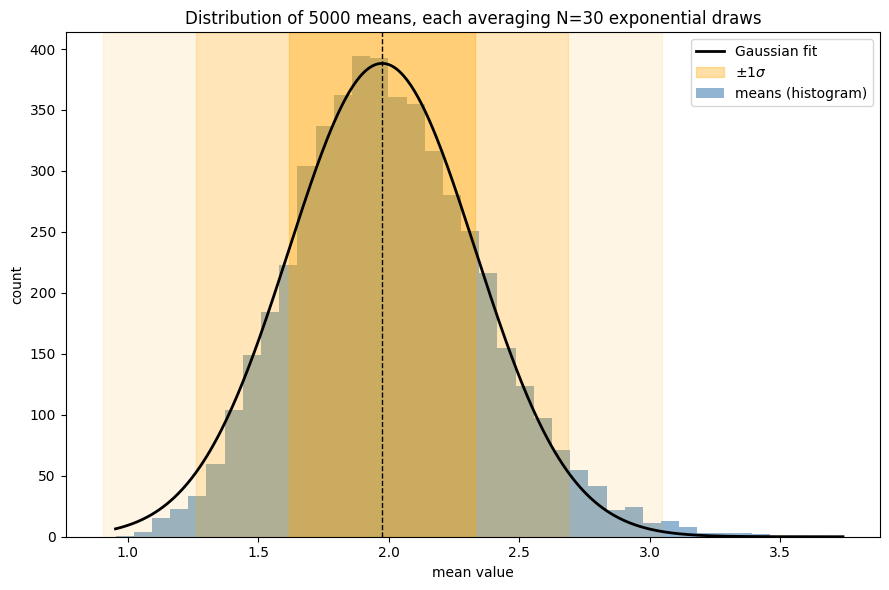

Fraction of means within 1 sigma: 0.685  (expect ~0.683)
Fraction of means within 2 sigma: 0.952  (expect ~0.954)
Fraction of means within 3 sigma: 0.993  (expect ~0.997)


In [8]:
plt.figure(figsize=(9, 6))
plt.bar(centers, counts, width=(edges[1]-edges[0]), color='steelblue', alpha=0.6, label='means (histogram)')

xx = np.linspace(means.min(), means.max(), 400)
plt.plot(xx, gaussian(xx, *popt), 'k-', lw=2, label='Gaussian fit')

for k, alpha in zip([1, 2, 3], [0.35, 0.20, 0.10]):
    plt.axvspan(mu_fit - k*sigma_fit, mu_fit + k*sigma_fit, color='orange', alpha=alpha,
                label=f'$\\pm{k}\\sigma$' if k == 1 else None)

plt.axvline(mu_fit, color='k', ls='--', lw=1)
plt.xlabel('mean value')
plt.ylabel('count')
plt.title(f'Distribution of {n_experiments} means, each averaging N={N} exponential draws')
plt.legend()
plt.tight_layout()
plt.show()

within_1s = np.mean(np.abs(means - mu_fit) <= sigma_fit)
within_2s = np.mean(np.abs(means - mu_fit) <= 2*sigma_fit)
within_3s = np.mean(np.abs(means - mu_fit) <= 3*sigma_fit)
print(f'Fraction of means within 1 sigma: {within_1s:.3f}  (expect ~0.683)')
print(f'Fraction of means within 2 sigma: {within_2s:.3f}  (expect ~0.954)')
print(f'Fraction of means within 3 sigma: {within_3s:.3f}  (expect ~0.997)')


## 8. Takeaways

- The exponential distribution is about as far from a bell curve as a simple distribution gets: bounded
  on one side, sharply peaked, long-tailed, skewness fixed at 2 no matter the scale.
- Averaging $N$ exponential draws together still converges to a **symmetric Gaussian**, centered at the
  same mean the exponential distribution has, with width shrinking as $\sigma_x/\sqrt N$ -- exactly the
  same law as for the uniform distribution.
- The skewness of the distribution of means falls off as $1/\sqrt N$, which is *why* the bell shape
  emerges: any asymmetry in the original distribution gets diluted away faster than the width shrinks.
- This is the real content of the Central Limit Theorem: it's not a fact about uniform or exponential
  distributions specifically, it's a fact about **sums (or averages) of many independent random
  quantities**, whatever distribution they individually came from -- with only mild conditions (finite
  mean and variance) required.